In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_within_vs_between_neuron_distances,
    plot_spike_to_avg_distances,
)
import config
from config import SPE1_PICKLE_ROOT

In [2]:
cluster_pickle_dir = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles')
spike_fit_dir      = os.path.join(SPE1_PICKLE_ROOT, 'spike_fit_pickles')

In [3]:
df_master = compile_experiment_results(cluster_pickle_dir)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)
df_master = df_master.sort_values(['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])

## Within-cell vs between-cell waveform distances

Do waveform clusters within a single neuron produce differences comparable to differences
between neurons?  If the within-cell cluster distance is in the same range as between-cell
distances, the clustering is picking up biologically meaningful variability — the cell is
as variable internally as it is different from its neighbours.

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2265: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


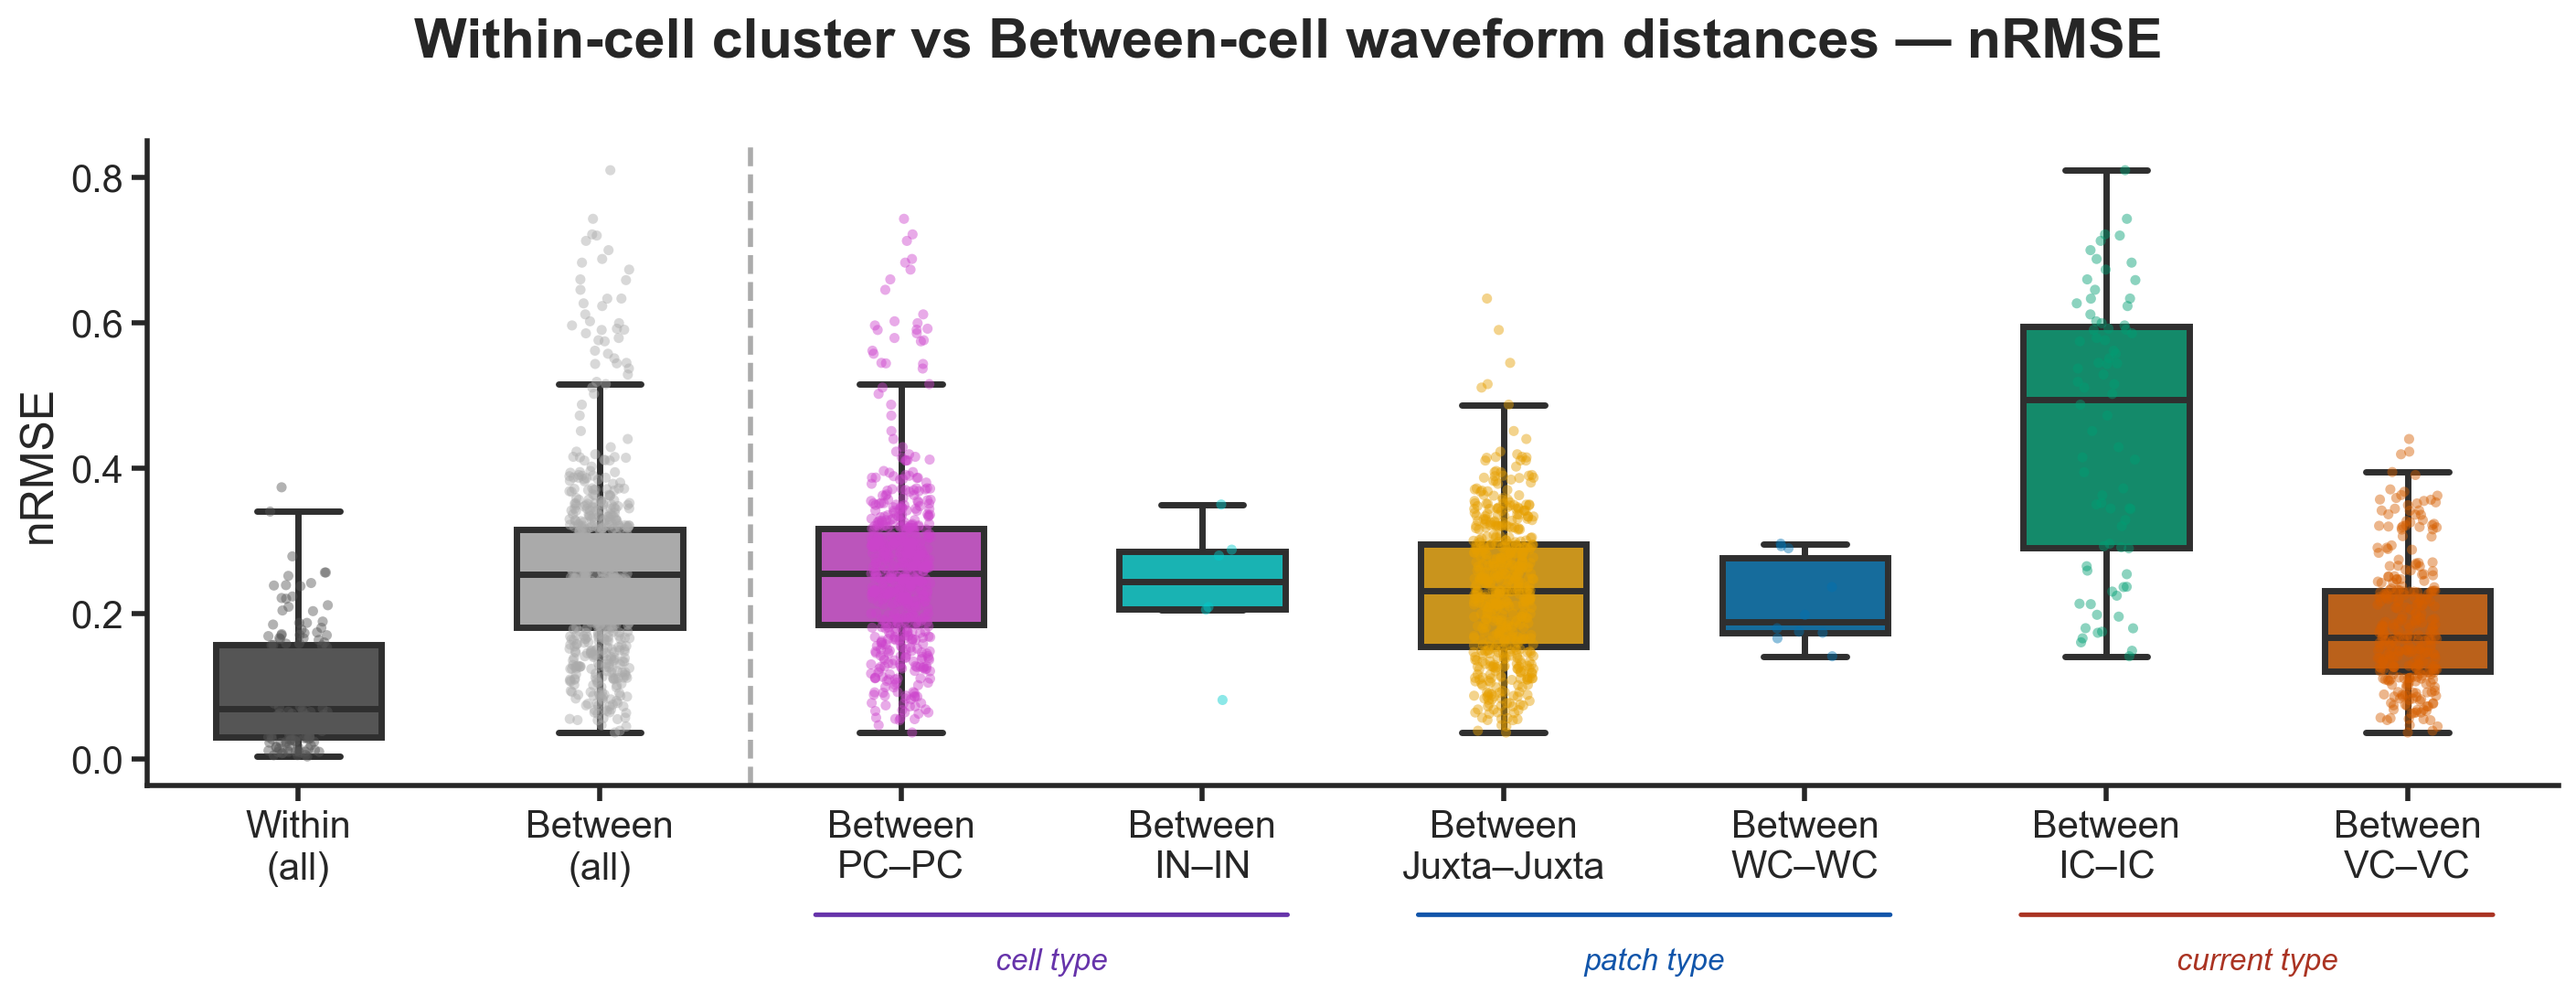


── nRMSE ──
  Within (all)          : median=0.069  IQR=[0.030, 0.157]  n=151
  Between (all)         : median=0.254  IQR=[0.181, 0.316]  n=703
  Between PC–PC         : median=0.255  IQR=[0.184, 0.317]  n=561
  Between IN–IN         : median=0.244  IQR=[0.206, 0.286]  n=6
  Between Juxta–Juxta   : median=0.232  IQR=[0.154, 0.295]  n=528
  Between WC–WC         : median=0.189  IQR=[0.174, 0.276]  n=10
  Between IC–IC         : median=0.494  IQR=[0.290, 0.595]  n=78
  Between VC–VC         : median=0.167  IQR=[0.120, 0.231]  n=300


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2265: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


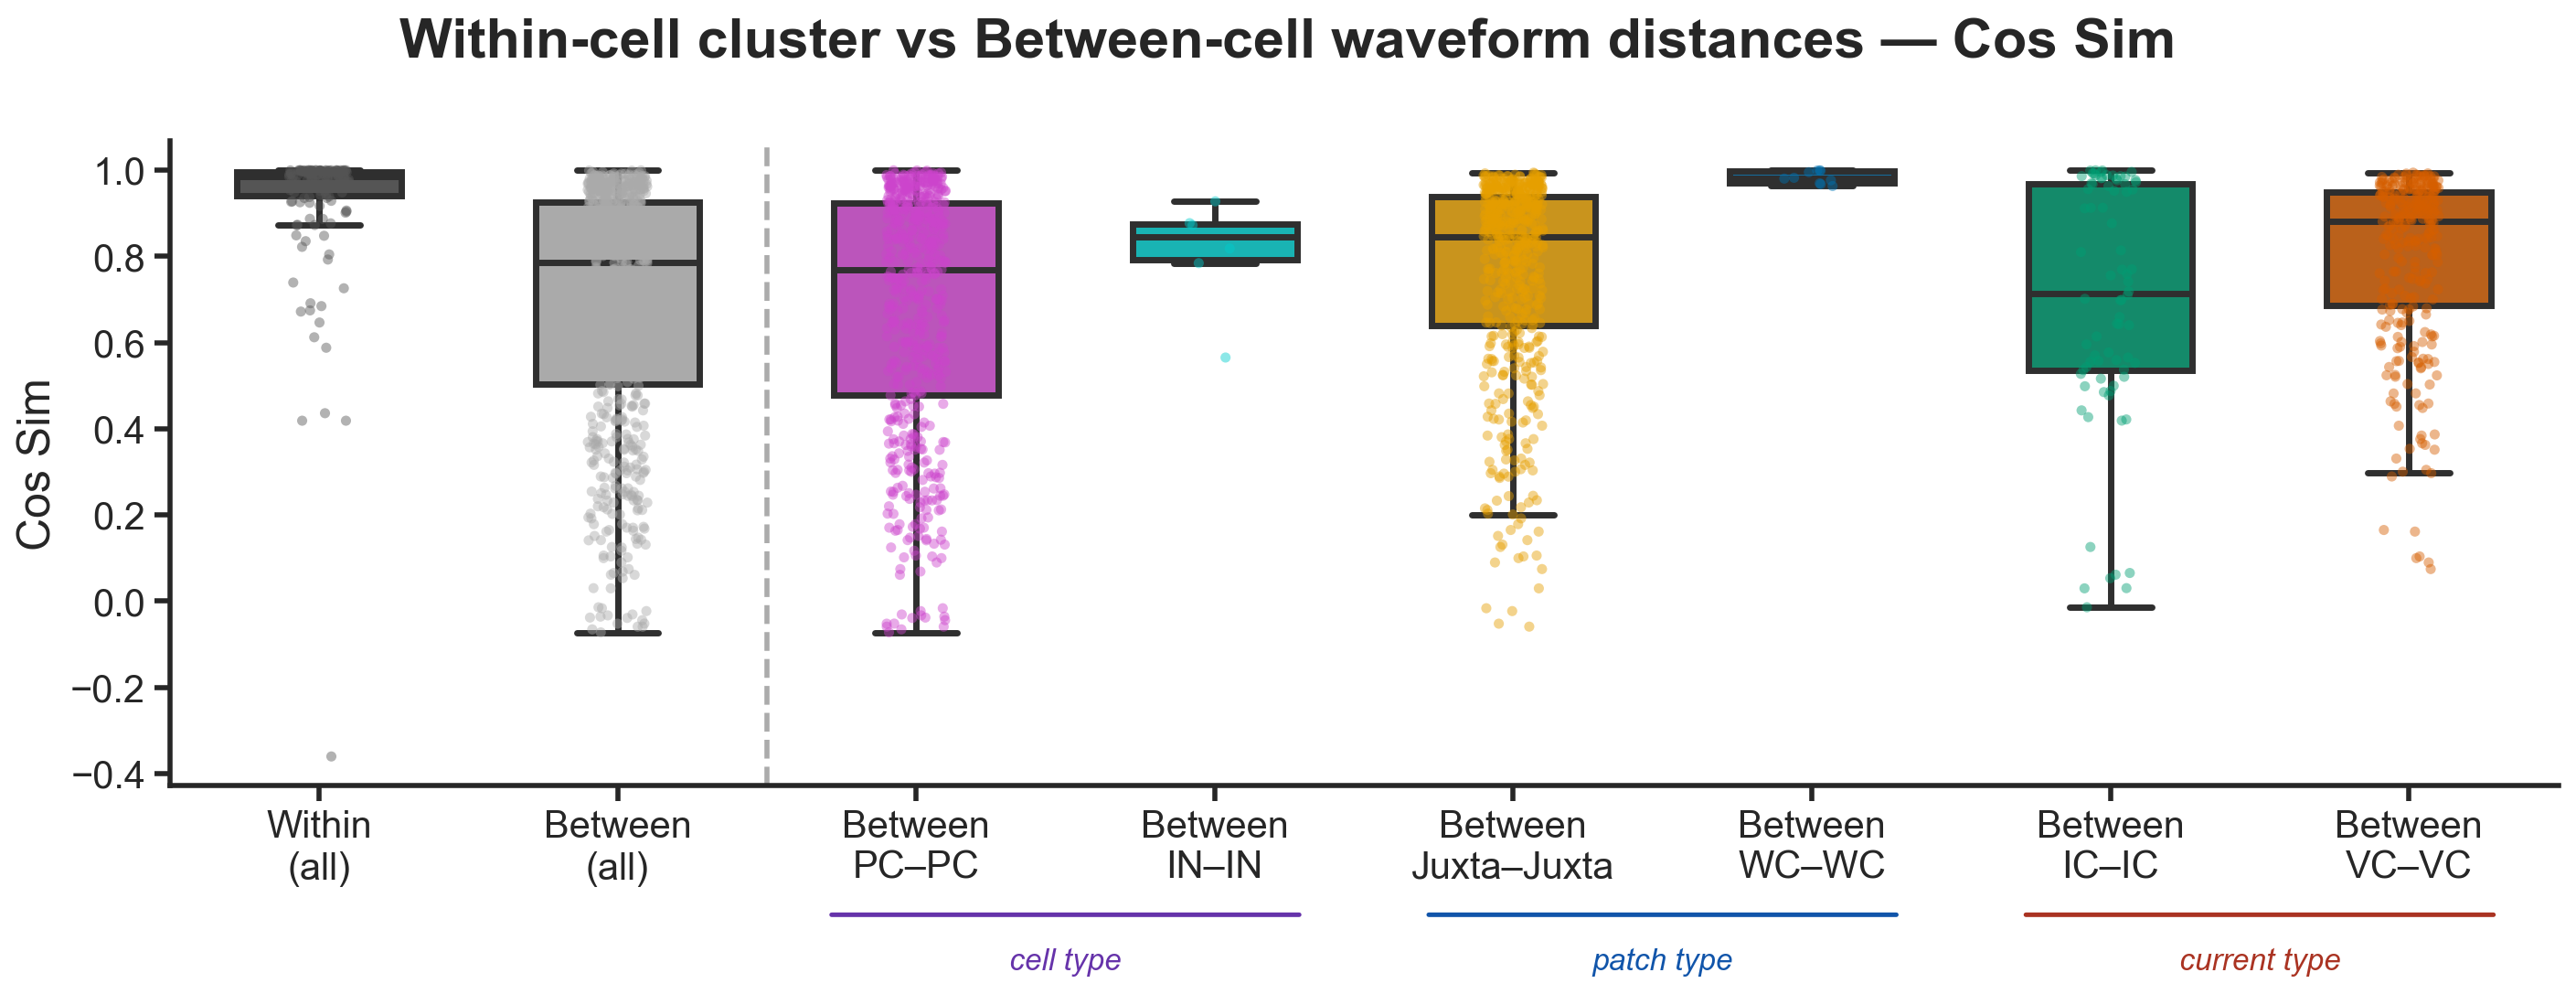


── Cos Sim ──
  Within (all)          : median=0.985  IQR=[0.941, 0.997]  n=151
  Between (all)         : median=0.785  IQR=[0.503, 0.926]  n=703
  Between PC–PC         : median=0.769  IQR=[0.478, 0.924]  n=561
  Between IN–IN         : median=0.845  IQR=[0.793, 0.876]  n=6
  Between Juxta–Juxta   : median=0.846  IQR=[0.640, 0.939]  n=528
  Between WC–WC         : median=0.981  IQR=[0.971, 0.998]  n=10
  Between IC–IC         : median=0.714  IQR=[0.536, 0.969]  n=78
  Between VC–VC         : median=0.881  IQR=[0.686, 0.949]  n=300


In [4]:
plot_within_vs_between_neuron_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    half_win=75,
    n_bootstrap=2000,
)

Loaded 43 cells, 167,006 total spikes
Between: 7,014,252 spike-to-avg comparisons across 43 cells


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2435: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2438: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


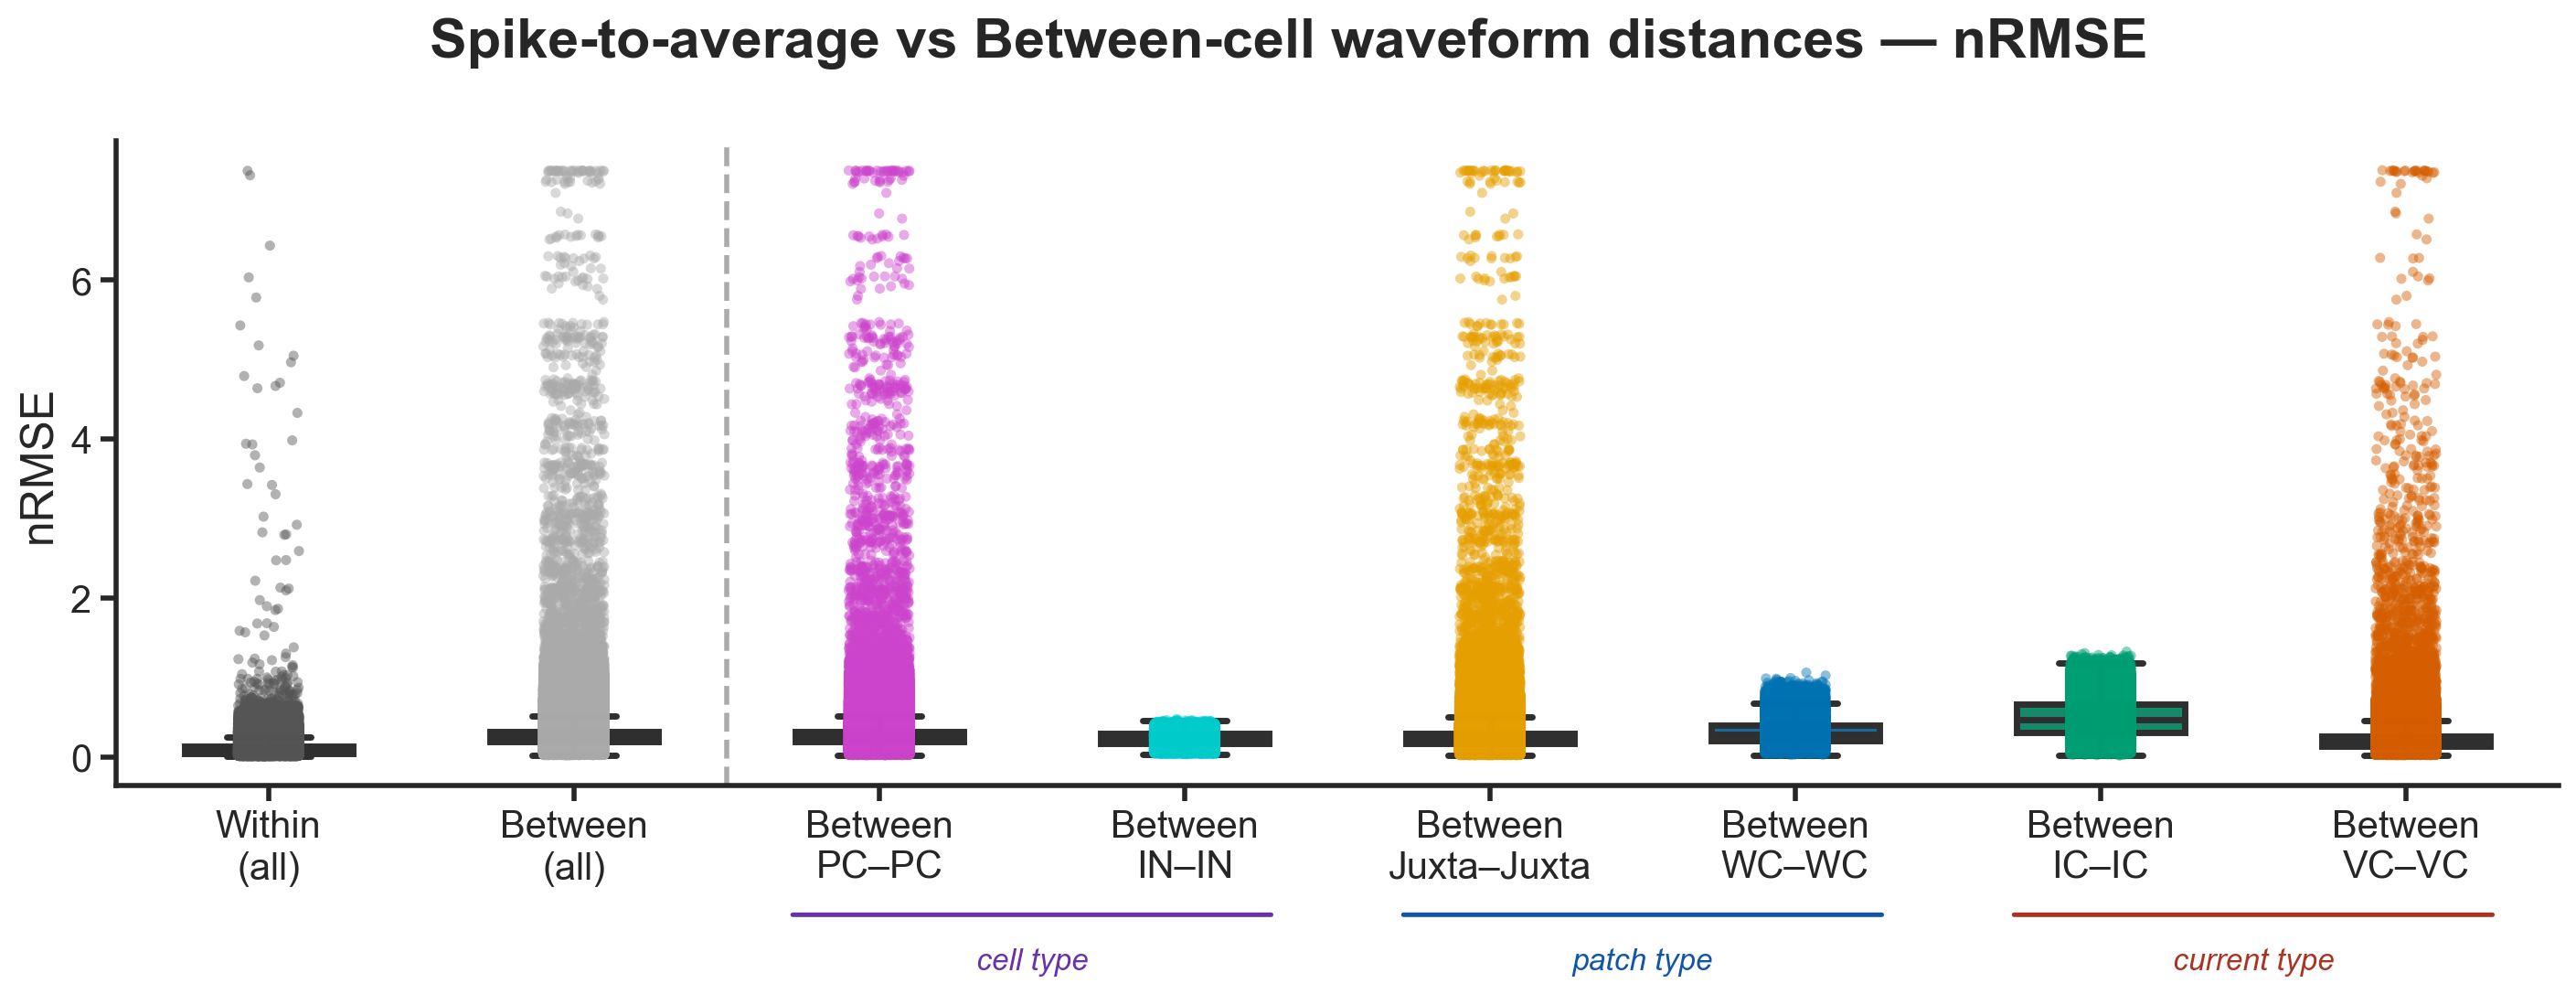


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.190, 0.320]  n=7014252
  Between PC–PC         : median=0.263  IQR=[0.196, 0.324]  n=4534992
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=205170
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=5460016
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752
  Between IC–IC         : median=0.473  IQR=[0.313, 0.662]  n=680748
  Between VC–VC         : median=0.191  IQR=[0.133, 0.261]  n=3198033


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2435: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2438: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


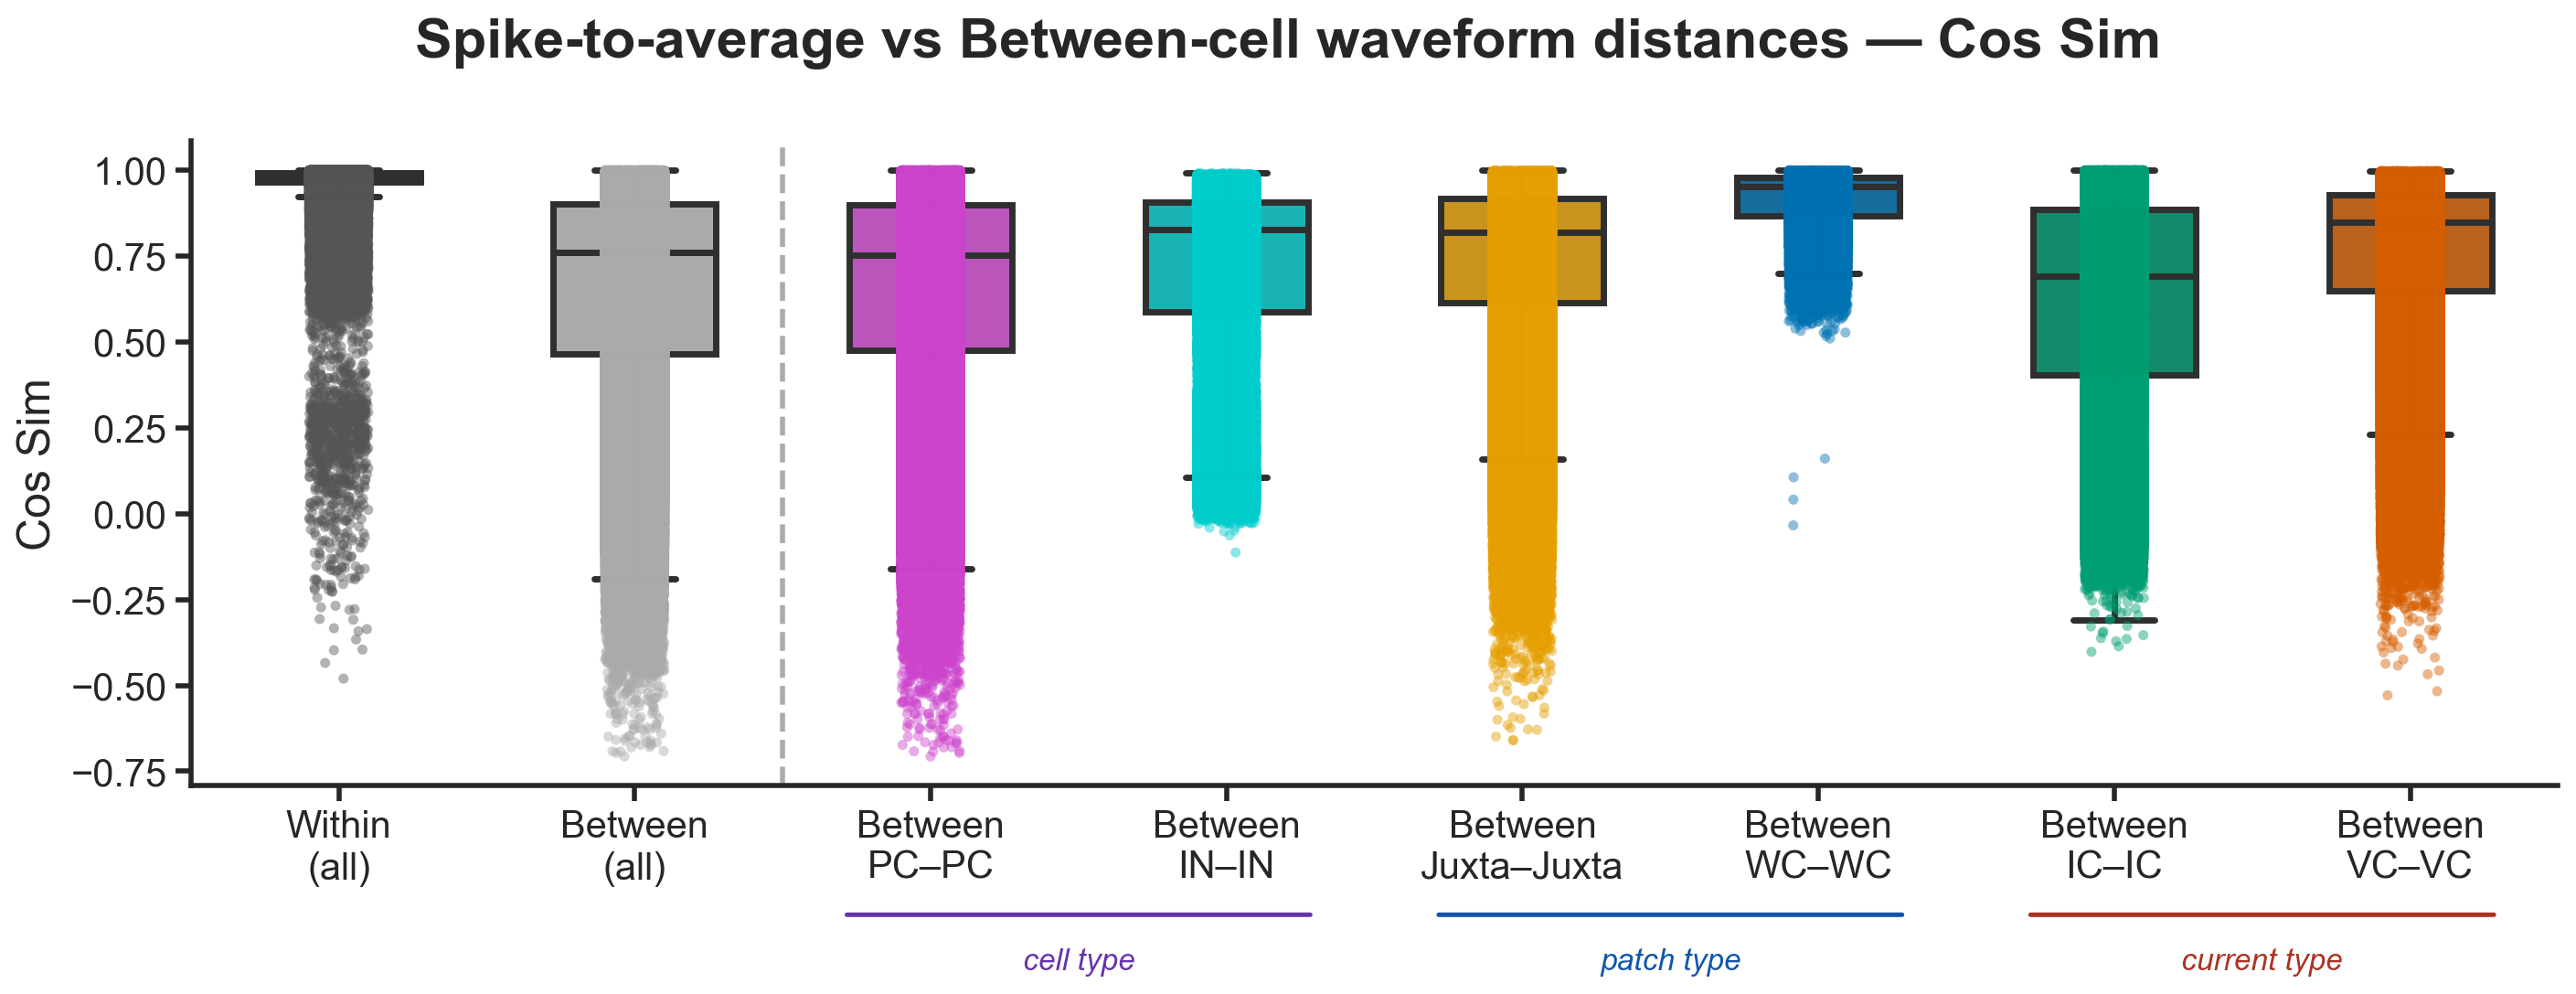


── Cos Sim (spike-to-avg) ──
  Within (all)          : median=0.984  IQR=[0.965, 0.992]  n=167006
  Between (all)         : median=0.761  IQR=[0.466, 0.903]  n=7014252
  Between PC–PC         : median=0.752  IQR=[0.476, 0.900]  n=4534992
  Between IN–IN         : median=0.828  IQR=[0.587, 0.908]  n=205170
  Between Juxta–Juxta   : median=0.819  IQR=[0.615, 0.918]  n=5460016
  Between WC–WC         : median=0.953  IQR=[0.868, 0.979]  n=77752
  Between IC–IC         : median=0.692  IQR=[0.403, 0.886]  n=680748
  Between VC–VC         : median=0.848  IQR=[0.649, 0.928]  n=3198033


In [5]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
)

Between-cell nRMSE reflects the typical waveform difference between any two randomly chosen
neurons in this dataset.  If within-cell cluster nRMSE reaches the lower tail of the
between-cell distribution, the clusters have biological-scale separations.  If within-cell
is entirely below between-cell, the clusters are sub-neuronal variability that doesn't
reach the level of distinguishing cells — which is still informative but means caution is
warranted in interpreting the clusters as discrete functional states.